c:\Users\julia\AppData\Local\Programs\Python\Python310\lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


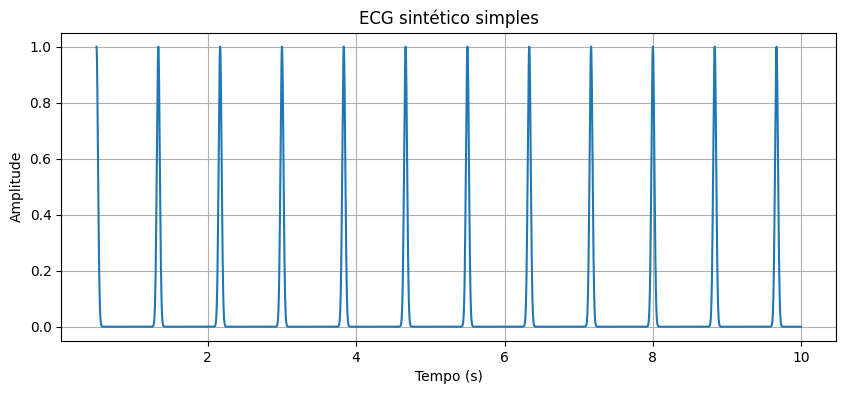

In [1]:
%run filtros.ipynb


# Módulo 2 — Aplicação no Sinal Sintético

Aplica LMS, NLMS e DWT ao ECG sintético contaminado com cada tipo de ruído separadamente.

## Definição dos Ruídos

Três fontes geradas separadamente para análise individual.

In [2]:
ruido = np.sin(2*np.pi*60*tempo) #senoide 60 Hz
ruido_2 = np.sin(2*np.pi*0.2*tempo) #senoide 0.2 Hz
ruido_3 = np.random.randn(len(tempo))  #ruido aleatorio

In [ ]:

ecg_ruidoso = ecg + ruido #sinal apenas com o ruido de 60 hz

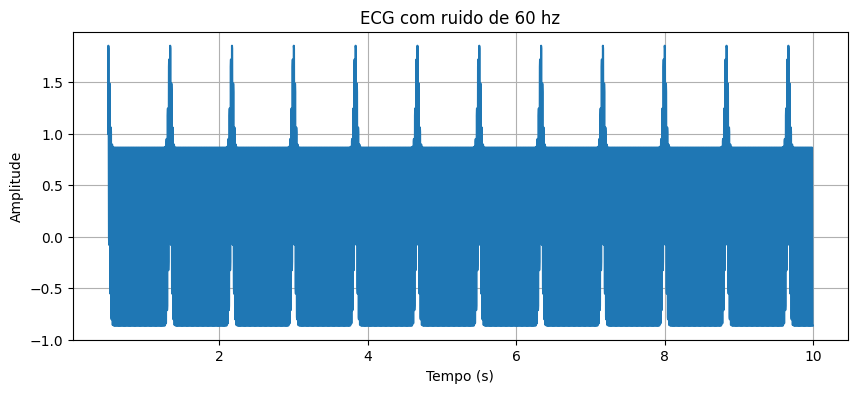

In [4]:
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg_ruidoso)
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("ECG com ruido de 60 hz")
plt.grid()
plt.show()

## Análise em Frequência (FFT)

Identifica as componentes espectrais de cada ruído antes da filtragem.

## Análise em Frequência

Agora vamos analisar os sinais e os ruídos no domínio da frequência. Isso ajuda a identificar quais componentes dominam cada sinal e facilita a comparação entre eles.

In [5]:
fft_ecg = np.abs(np.fft.rfft(ecg))
freqs = np.fft.rfftfreq(len(ecg), d=1/frequencia_amostragem)

fft_60hz = np.abs(np.fft.rfft(ruido)) #ruido de 60hz no dominio da frequencia
fft_02hz = np.abs(np.fft.rfft(ruido_2))  #ruido de 0.2 hz no dominio da frequencia
fft_aletorio = np.abs(np.fft.rfft(ruido_3))  #ruido aleatorio  no dominio da frequencia
fft_ruidoso = np.abs(np.fft.rfft(ecg_ruidoso)) #sinal ideia + ruido de 60hz no dominio da frequencia

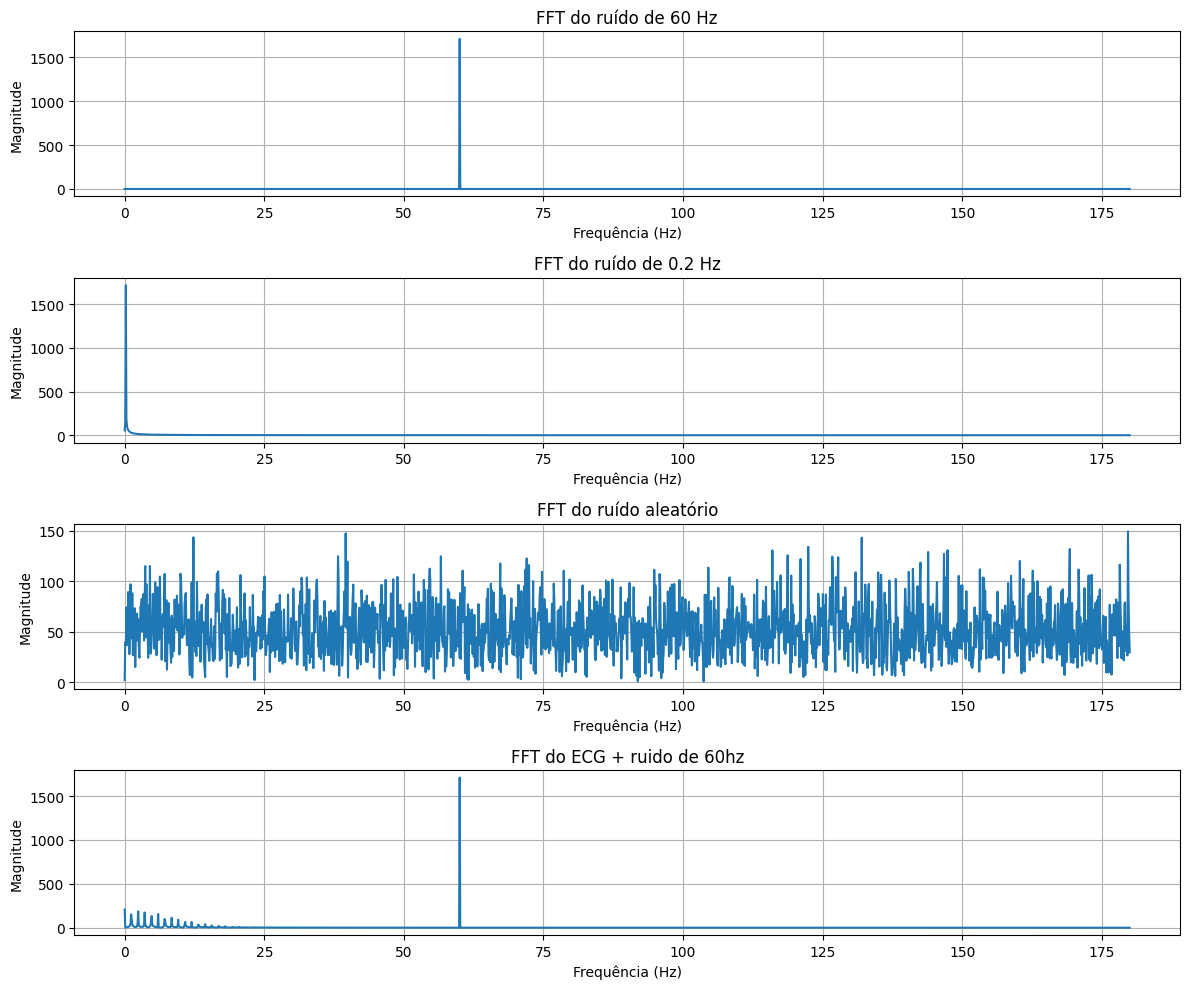

In [6]:
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(freqs, fft_60hz)
plt.title("FFT do ruído de 60 Hz")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(4, 1, 2)
plt.plot(freqs, fft_02hz)
plt.title("FFT do ruído de 0.2 Hz")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(4, 1, 3)
plt.plot(freqs, fft_aletorio)
plt.title("FFT do ruído aleatório")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.subplot(4, 1, 4)
plt.plot(freqs, fft_ruidoso)
plt.title("FFT do ECG + ruido de 60hz")
plt.xlabel("Frequência (Hz)")
plt.ylabel("Magnitude")
plt.grid()

plt.tight_layout()
plt.show()

## Filtragem do Ruído de 60 Hz

Sinal de referência: senoide pura de 60 Hz com pequeno ruído aditivo.

## LMS

O método LMS (Least Mean Squares) é uma técnica adaptativa usada para reduzir ruídos de forma iterativa. A ideia é ajustar os coeficientes do filtro para minimizar o erro entre o sinal desejado e a saída filtrada.

No contexto deste trabalho, ele pode ser aplicado para tentar remover interferências do ECG ruidoso sem depender apenas de um filtro fixo. Isso é útil quando o ruído muda ao longo do tempo ou quando se quer acompanhar variações do sinal em tempo real.

Em termos práticos, o LMS atualiza os pesos do filtro a cada amostra, usando o erro instantâneo como base para a correção.

In [7]:
sinal_ref = ruido + 0.05 * np.random.randn(len(tempo)) #sinal de referência, correlacionado só com a interferência de 60 Hz com um ruido

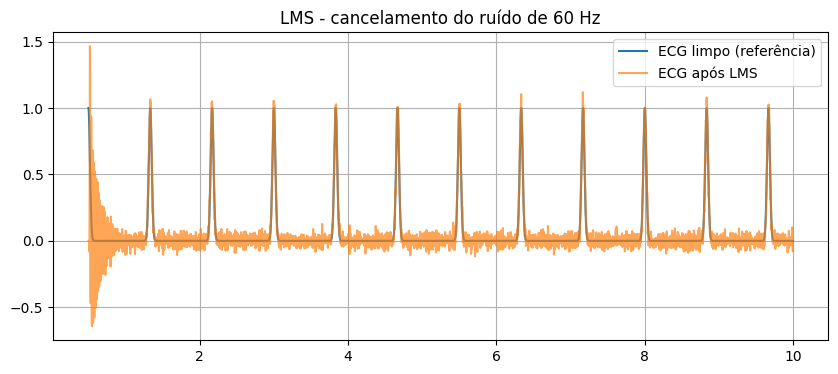

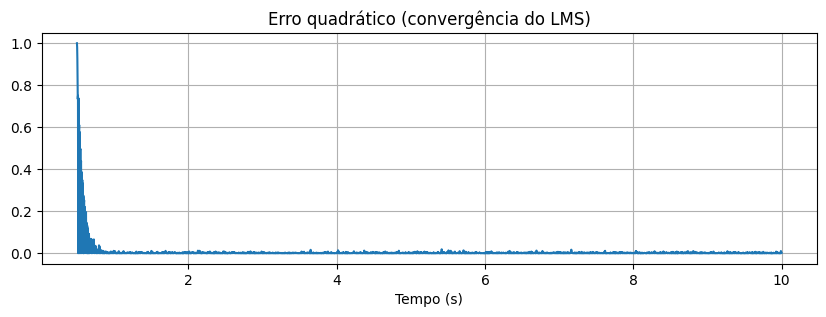

In [8]:
mu = 0.01
M = 5

ecg_lms, ruido_estimado_lms, pesos_lms = lms_filter(ecg_ruidoso, sinal_ref, mu, M)

plt.figure(figsize=(10,4))
plt.plot(tempo, ecg, label="ECG limpo (referência)")
plt.plot(tempo, ecg_lms, label="ECG após LMS", alpha=0.7)
plt.legend()
plt.title("LMS - cancelamento do ruído de 60 Hz")
plt.grid()
plt.show()

# curva de convergência: erro ao quadrado por amostra
plt.figure(figsize=(10,3))
plt.plot(tempo, ecg_lms**2 if False else (ecg_lms - ecg)**2)
plt.title("Erro quadrático (convergência do LMS)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

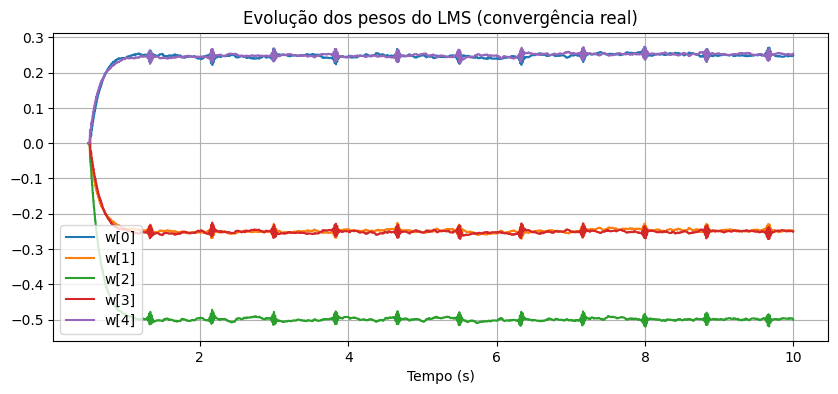

In [9]:
plt.figure(figsize=(10,4))
for i in range(M):
    plt.plot(tempo, pesos_lms[:, i], label=f"w[{i}]")
plt.legend()
plt.title("Evolução dos pesos do LMS (convergência real)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

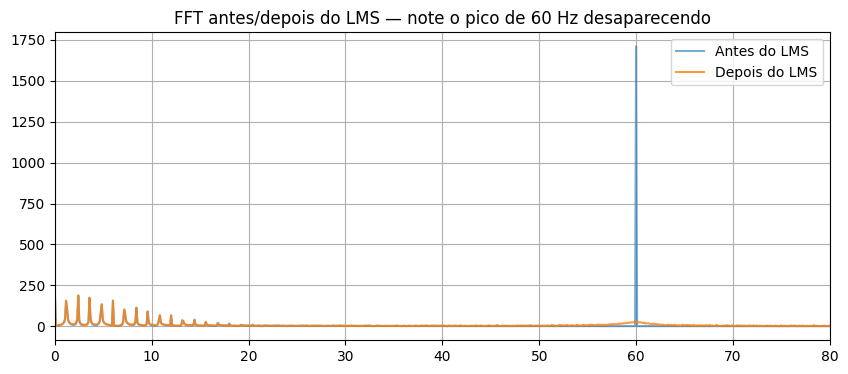

In [10]:
fft_antes = np.abs(np.fft.rfft(ecg_ruidoso))
fft_depois = np.abs(np.fft.rfft(ecg_lms))
freqs = np.fft.rfftfreq(len(ecg_ruidoso), d=1/frequencia_amostragem)

plt.figure(figsize=(10,4))
plt.plot(freqs, fft_antes, label="Antes do LMS", alpha=0.6)
plt.plot(freqs, fft_depois, label="Depois do LMS", alpha=0.8)
plt.xlim(0, 80)
plt.legend()
plt.title("FFT antes/depois do LMS — note o pico de 60 Hz desaparecendo")
plt.grid()
plt.show()

In [11]:
mu_nlms = 0.05
M = 5

ecg_nlms, ruido_estimado_nlms, pesos_nlms = nlms_filter(ecg_ruidoso, sinal_ref, mu_nlms, M)

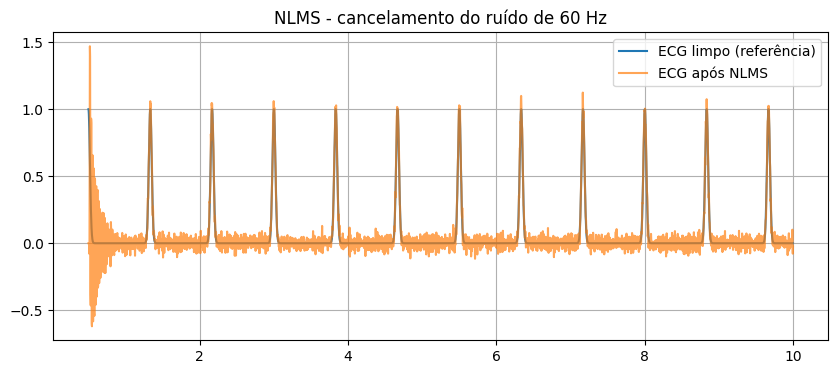

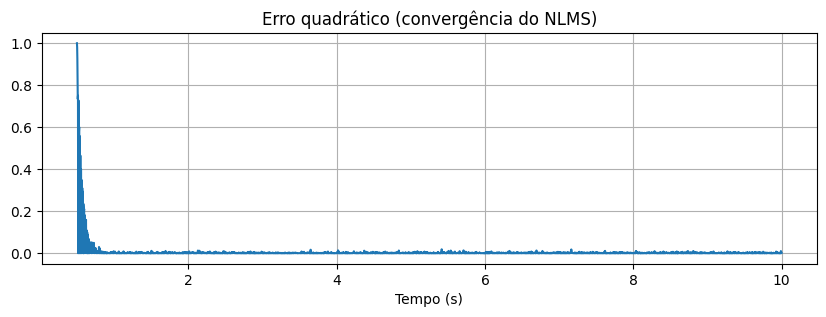

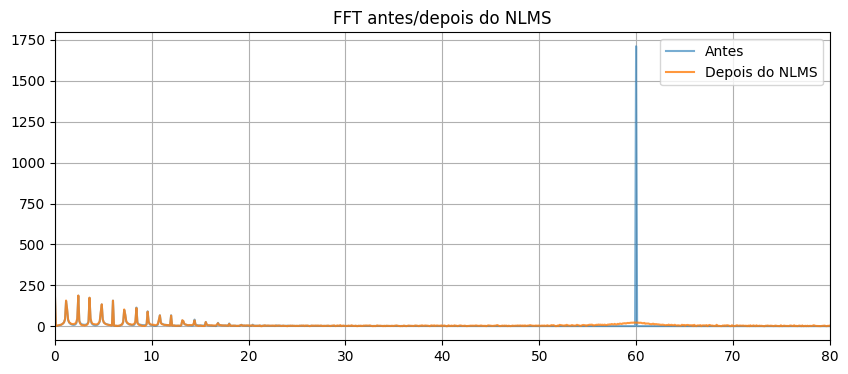

In [12]:
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg, label="ECG limpo (referência)")
plt.plot(tempo, ecg_nlms, label="ECG após NLMS", alpha=0.7)
plt.legend()
plt.title("NLMS - cancelamento do ruído de 60 Hz")
plt.grid()
plt.show()

# Erro quadrático
plt.figure(figsize=(10,3))
plt.plot(tempo, (ecg_nlms - ecg)**2)
plt.title("Erro quadrático (convergência do NLMS)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

# FFT antes/depois
fft_depois_nlms = np.abs(np.fft.rfft(ecg_nlms))
plt.figure(figsize=(10,4))
plt.plot(freqs, fft_antes, label="Antes", alpha=0.6)
plt.plot(freqs, fft_depois_nlms, label="Depois do NLMS", alpha=0.8)
plt.xlim(0, 80)
plt.legend()
plt.title("FFT antes/depois do NLMS")
plt.grid()
plt.show()

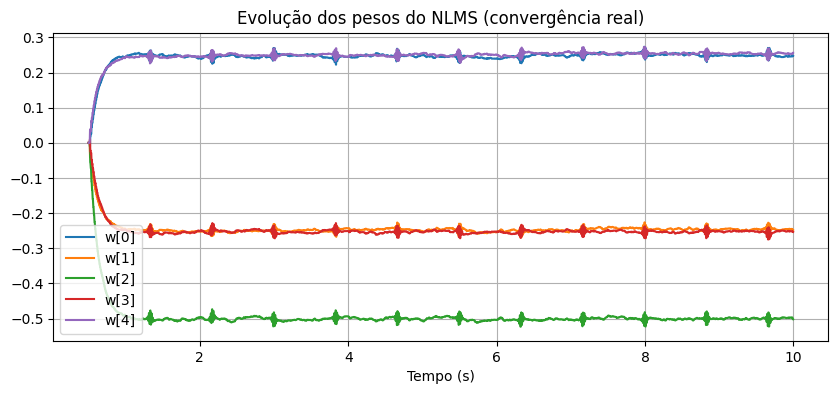

In [13]:
plt.figure(figsize=(10,4))
for i in range(M):
    plt.plot(tempo, pesos_nlms[:, i], label=f"w[{i}]")
plt.legend()
plt.title("Evolução dos pesos do NLMS (convergência real)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

Magnitude em 60Hz — antes: 1710.9 | LMS: 29.4 | NLMS: 22.4


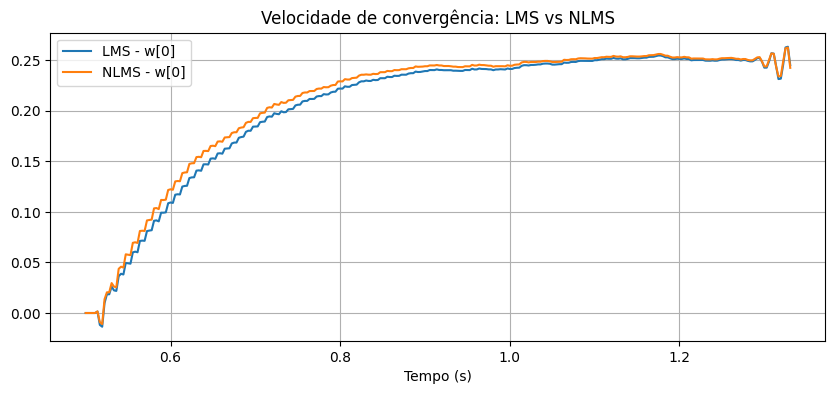

In [14]:
freqs = np.fft.rfftfreq(len(ecg_ruidoso), d=1/frequencia_amostragem)
idx60 = np.argmin(np.abs(freqs - 60))

mag_antes = np.abs(np.fft.rfft(ecg_ruidoso))[idx60]
mag_lms   = np.abs(np.fft.rfft(ecg_lms))[idx60]
mag_nlms  = np.abs(np.fft.rfft(ecg_nlms))[idx60]

print(f"Magnitude em 60Hz — antes: {mag_antes:.1f} | LMS: {mag_lms:.1f} | NLMS: {mag_nlms:.1f}")

plt.figure(figsize=(10,4))
plt.plot(tempo[:300], pesos_lms[:300, 0], label="LMS - w[0]")
plt.plot(tempo[:300], pesos_nlms[:300, 0], label="NLMS - w[0]")
plt.legend()
plt.title("Velocidade de convergência: LMS vs NLMS")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

c:\Users\julia\AppData\Local\Programs\Python\Python310\lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 9 is too high: all coefficients will experience boundary effects.
  warnings.warn(


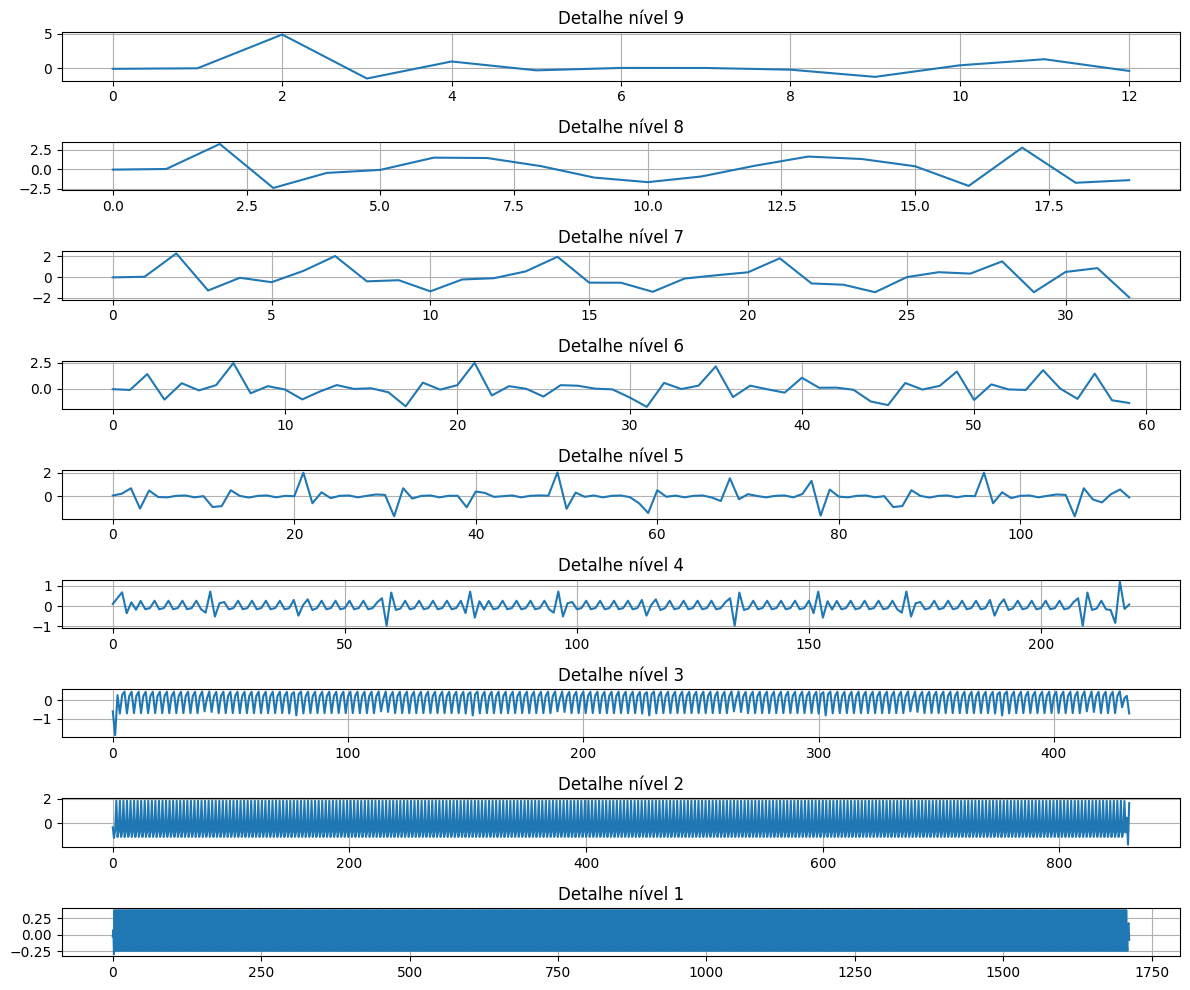

In [15]:
wavelet = 'db4'   # Daubechies ordem 4, boa para ECG
nivel = 9       # níveis de decomposição

# Decompõe
coeffs = pywt.wavedec(ecg_ruidoso, wavelet, level=nivel)

# coeffs[0]       → aproximação (nível mais grosso)
# coeffs[1..5]    → detalhes do nível 5 ao 1

# Visualiza os coeficientes de detalhe
fig, axs = plt.subplots(nivel, 1, figsize=(12, 10))
for i, c in enumerate(coeffs[1:], 1):
    axs[i-1].plot(c)
    axs[i-1].set_title(f"Detalhe nível {nivel+1-i}")
    axs[i-1].grid()
plt.tight_layout()
plt.show()

In [16]:
# Threshold universal de Donoho & Johnstone
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(ecg_ruidoso)))

print(f"Threshold calculado: {threshold:.4f}")
# Threshold adaptativo por nível
coeffs_filtrados = [coeffs[0]]# Volta ao threshold global, mas com fator de escala ajustável
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
fator = 0.4 
threshold = fator * sigma * np.sqrt(2 * np.log(len(ecg_ruidoso)))

coeffs_filtrados = [coeffs[0]]
for c in coeffs[1:]:
    coeffs_filtrados.append(pywt.threshold(c, threshold, mode='soft'))

Threshold calculado: 1.4604


In [17]:
for i, c in enumerate(coeffs):
    print(f"Coef {i}: max = {np.max(np.abs(c)):.4f}")

Coef 0: max = 27.4571
Coef 1: max = 4.9150
Coef 2: max = 3.2654
Coef 3: max = 2.2640
Coef 4: max = 2.4874
Coef 5: max = 2.0564
Coef 6: max = 1.2005
Coef 7: max = 1.8653
Coef 8: max = 1.8495
Coef 9: max = 0.3697


In [18]:
ecg_dwt = pywt.waverec(coeffs_filtrados, wavelet)

# Garante o mesmo tamanho (waverec pode adicionar 1 amostra)
ecg_dwt = ecg_dwt[:len(ecg)]

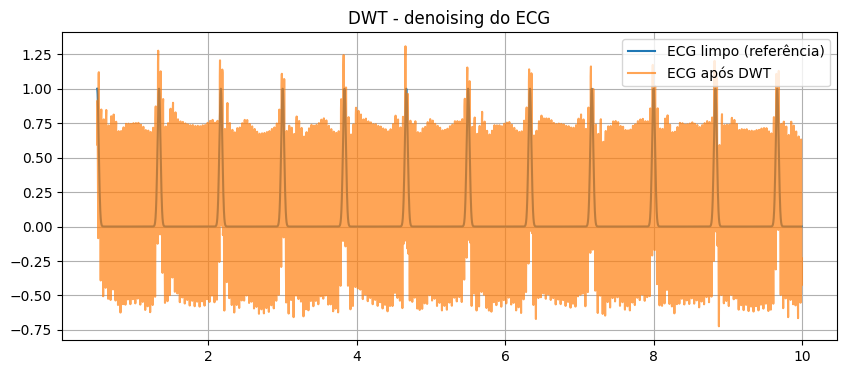

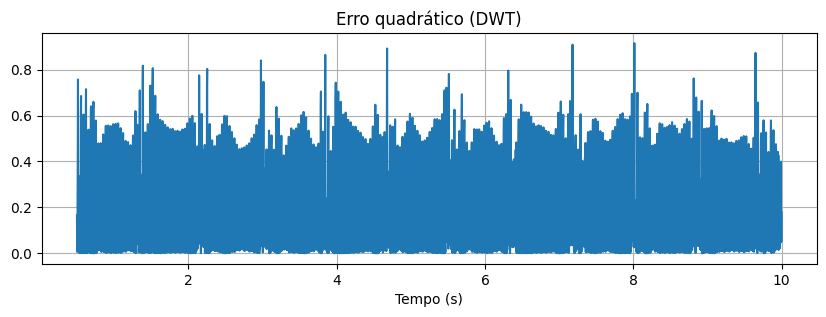

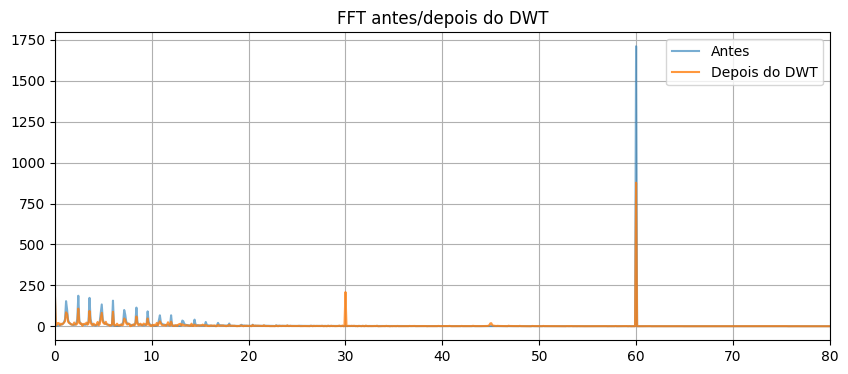

In [19]:
plt.figure(figsize=(10,4))
plt.plot(tempo, ecg, label="ECG limpo (referência)")
plt.plot(tempo, ecg_dwt, label="ECG após DWT", alpha=0.7)
plt.legend()
plt.title("DWT - denoising do ECG")
plt.grid()
plt.show()

# Erro quadrático
plt.figure(figsize=(10,3))
plt.plot(tempo, (ecg_dwt - ecg)**2)
plt.title("Erro quadrático (DWT)")
plt.xlabel("Tempo (s)")
plt.grid()
plt.show()

# FFT antes/depois
fft_dwt = np.abs(np.fft.rfft(ecg_dwt))
plt.figure(figsize=(10,4))
plt.plot(freqs, fft_antes, label="Antes", alpha=0.6)
plt.plot(freqs, fft_dwt, label="Depois do DWT", alpha=0.8)
plt.xlim(0, 80)
plt.legend()
plt.title("FFT antes/depois do DWT")
plt.grid()
plt.show()

## Comparação entre os sinais

Nesta etapa, a função `comparar_sinais` é usada para comparar o ECG original com os sinais obtidos após a filtragem adaptativa. A métrica utilizada é a SNR, que relaciona a potência do sinal limpo com a potência do erro entre o sinal processado e o sinal de referência. Assim, quanto maior for o valor de SNR, mais próximo o sinal filtrado está do ECG original e melhor foi a remoção do ruído.

In [20]:
snr_ruidoso = comparar_sinais(ecg, ecg_ruidoso)
snr_lms     = comparar_sinais(ecg, ecg_lms)
snr_nlms    = comparar_sinais(ecg, ecg_nlms)
snr_dwt     = comparar_sinais(ecg, ecg_dwt)

resultados = pd.DataFrame({
    'Método':  ['Sinal ruidoso', 'LMS', 'NLMS', 'DWT'],
    'SNR (dB)': [snr_ruidoso,  snr_lms, snr_nlms, snr_dwt]
})

print(resultados.to_string(index=False))

Potência sinal: 0.0430582394312799
Potência erro: 0.5000000000000004
Potência sinal: 0.0430582394312799
Potência erro: 0.006387973877508796
Potência sinal: 0.0430582394312799
Potência erro: 0.005935575091358185
Potência sinal: 0.0430582394312799
Potência erro: 0.1687470090773193
       Método   SNR (dB)
Sinal ruidoso -10.649137
          LMS   8.286931
         NLMS   8.605935
          DWT  -5.931798


### Interpretação dos Resultados — Ruído de 60 Hz

| Método | SNR esperado | Razão |
|--------|-------------|-------|
| LMS    | Alto (≥ 20 dB) | Referência `sin(2π·60·t)` é quase idêntica à interferência real → cancelamento direto e preciso |
| NLMS   | Ligeiramente superior ao LMS | Normalização pelo módulo de `x[n]` acelera a convergência |
| DWT    | Moderado | O pico de 60 Hz é estreito; o threshold pode distorcer o QRS no processo |

**Conclusão:** Para ruído de rede (60 Hz), **LMS e NLMS são superiores à DWT**.

## Filtragem do Ruído de 0.2 Hz

Deriva de linha de base: senoide de 0.2 Hz sobreposta ao ECG limpo.

In [21]:
# Sinal de referência para o ruído de 0.2 Hz
ecg_ruidoso_02 = ecg + ruido_2
sinal_ref_02 = ruido_2 + 0.05 * np.random.randn(len(tempo))


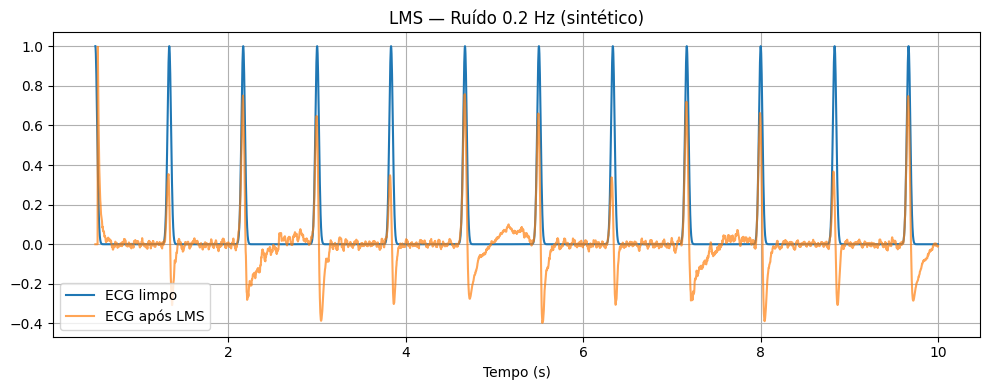

In [22]:
mu_02 = 0.01
M_02  = 10

ecg_lms_02, ruido_est_lms_02, pesos_lms_02 = lms_filter(ecg_ruidoso_02, sinal_ref_02, mu_02, M_02)

plt.figure(figsize=(10,4))
plt.plot(tempo, ecg,          label='ECG limpo')
plt.plot(tempo, ecg_lms_02,   label='ECG após LMS', alpha=0.7)
plt.legend(); plt.title('LMS — Ruído 0.2 Hz (sintético)'); plt.xlabel('Tempo (s)'); plt.grid(); plt.tight_layout(); plt.show()


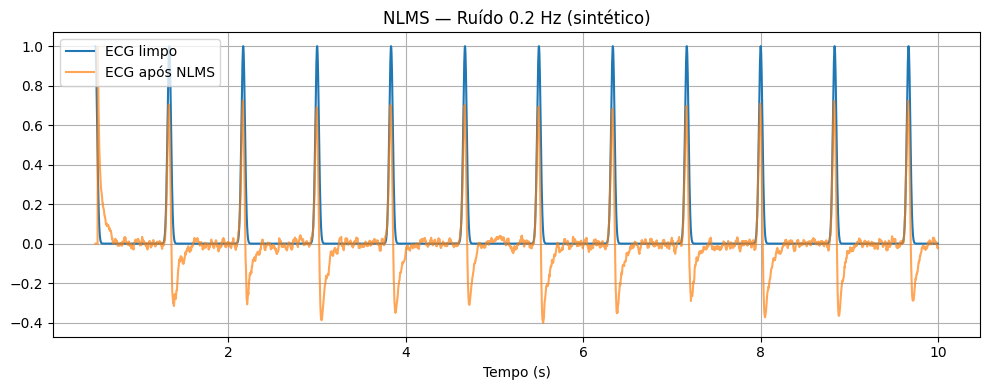

In [23]:
mu_nlms_02 = 0.05

ecg_nlms_02, ruido_est_nlms_02, pesos_nlms_02 = nlms_filter(ecg_ruidoso_02, sinal_ref_02, mu_nlms_02, M_02)

plt.figure(figsize=(10,4))
plt.plot(tempo, ecg,           label='ECG limpo')
plt.plot(tempo, ecg_nlms_02,   label='ECG após NLMS', alpha=0.7)
plt.legend(); plt.title('NLMS — Ruído 0.2 Hz (sintético)'); plt.xlabel('Tempo (s)'); plt.grid(); plt.tight_layout(); plt.show()


c:\Users\julia\AppData\Local\Programs\Python\Python310\lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 9 is too high: all coefficients will experience boundary effects.
  warnings.warn(


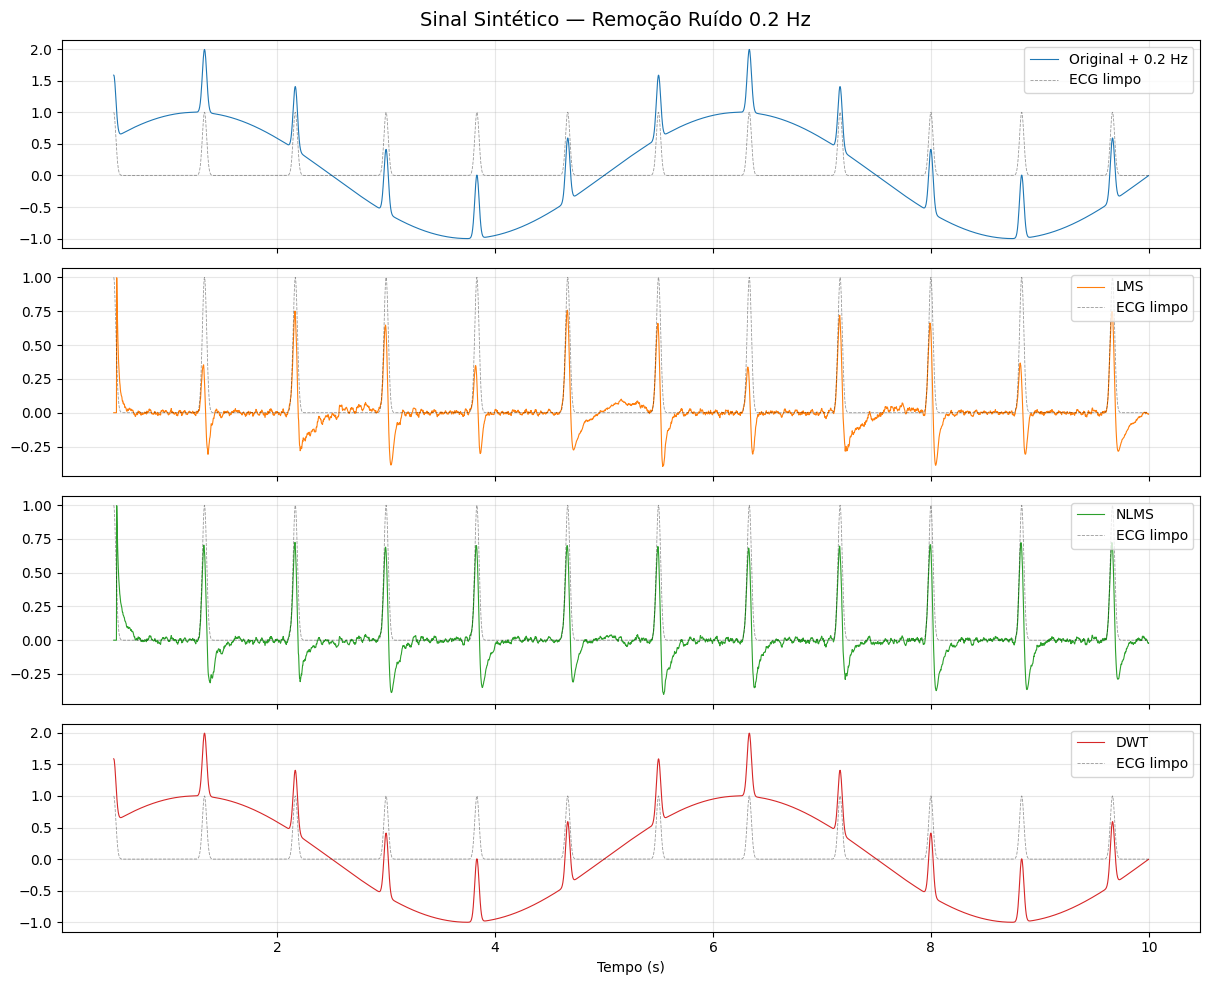

In [24]:
ecg_dwt_02 = dwt_filter(ecg_ruidoso_02, wavelet='db4', nivel=9)

fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Sinal Sintético — Remoção Ruído 0.2 Hz', fontsize=14)
for ax, sig, label, cor in zip(axs,
        [ecg_ruidoso_02, ecg_lms_02, ecg_nlms_02, ecg_dwt_02],
        ['Original + 0.2 Hz', 'LMS', 'NLMS', 'DWT'],
        ['tab:blue','tab:orange','tab:green','tab:red']):
    ax.plot(tempo, sig,  color=cor, linewidth=0.8, label=label)
    ax.plot(tempo, ecg, 'k--', linewidth=0.6, alpha=0.4, label='ECG limpo')
    ax.legend(loc='upper right'); ax.grid(alpha=0.3)
axs[-1].set_xlabel('Tempo (s)'); plt.tight_layout(); plt.show()


In [25]:
print("=== SNR Sintético — Ruído 0.2 Hz ===")
print("Antes da filtragem :", comparar_sinais(ecg, ecg_ruidoso_02))
print("LMS                :", comparar_sinais(ecg, ecg_lms_02))
print("NLMS               :", comparar_sinais(ecg, ecg_nlms_02))
print("DWT                :", comparar_sinais(ecg, ecg_dwt_02))


=== SNR Sintético — Ruído 0.2 Hz ===
Potência sinal: 0.0430582394312799
Potência erro: 0.5199669224203862
Antes da filtragem : -10.819194485839141
Potência sinal: 0.0430582394312799
Potência erro: 0.026890908998597734
LMS                : 2.044507853713605
Potência sinal: 0.0430582394312799
Potência erro: 0.02057096801802034
NLMS               : 3.2080153940147045
Potência sinal: 0.0430582394312799
Potência erro: 0.5199669224161239
DWT                : -10.819194485803541


### Interpretação dos Resultados — Ruído de 0.2 Hz

| Método | SNR esperado | Razão |
|--------|-------------|-------|
| LMS    | Moderado | Período longo (5 s) exige muitas amostras para convergência |
| NLMS   | Superior ao LMS | Normalização estabiliza o passo com período longo |
| DWT    | Variável | Eficaz se `nivel` for suficientemente alto; sensível ao threshold |

**Conclusão:** **NLMS é o mais equilibrado** para deriva de linha de base.

## Filtragem do Ruído Gaussiano

Ruído branco gaussiano: LMS/NLMS com delay-line, DWT com threshold Donoho & Johnstone.

In [26]:
np.random.seed(42)
ecg_ruidoso_g = ecg + ruido_3
D = 5  # delay para delay-line
sinal_ref_g = np.concatenate([np.zeros(D), ecg_ruidoso_g[:-D]])


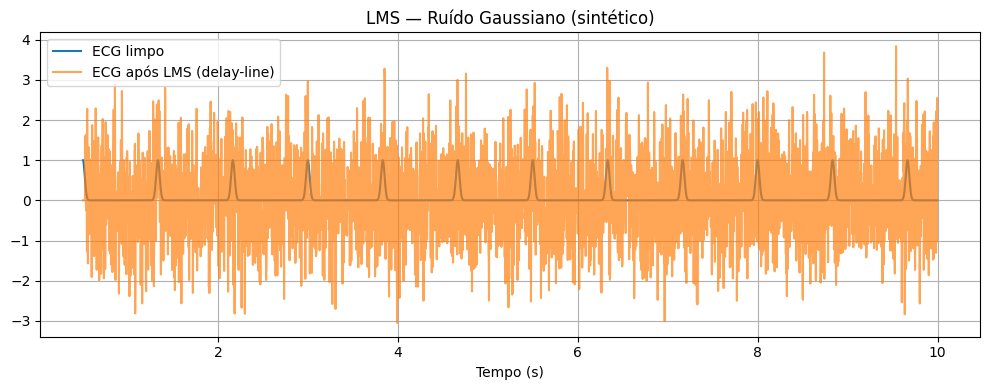

In [27]:
ecg_lms_g, _, _ = lms_filter(ecg_ruidoso_g, sinal_ref_g, mu=0.005, M=10)

plt.figure(figsize=(10,4))
plt.plot(tempo, ecg,        label='ECG limpo')
plt.plot(tempo, ecg_lms_g,  label='ECG após LMS (delay-line)', alpha=0.7)
plt.legend(); plt.title('LMS — Ruído Gaussiano (sintético)'); plt.xlabel('Tempo (s)'); plt.grid(); plt.tight_layout(); plt.show()


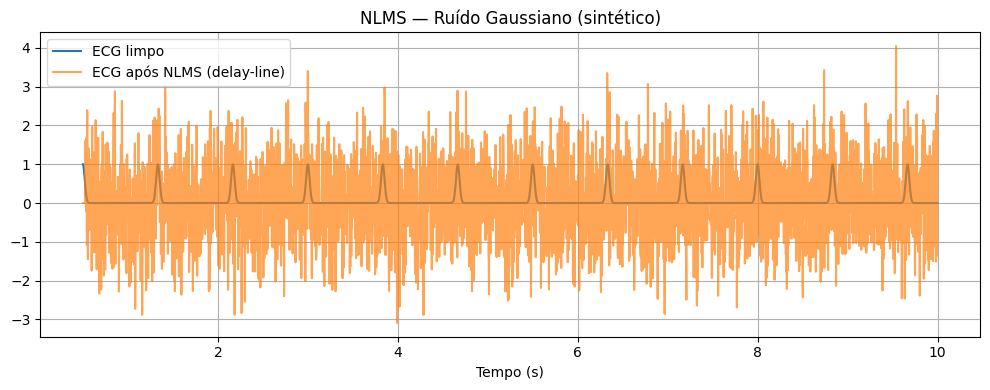

In [28]:
ecg_nlms_g, _, _ = nlms_filter(ecg_ruidoso_g, sinal_ref_g, mu=0.01, M=10)

plt.figure(figsize=(10,4))
plt.plot(tempo, ecg,         label='ECG limpo')
plt.plot(tempo, ecg_nlms_g,  label='ECG após NLMS (delay-line)', alpha=0.7)
plt.legend(); plt.title('NLMS — Ruído Gaussiano (sintético)'); plt.xlabel('Tempo (s)'); plt.grid(); plt.tight_layout(); plt.show()


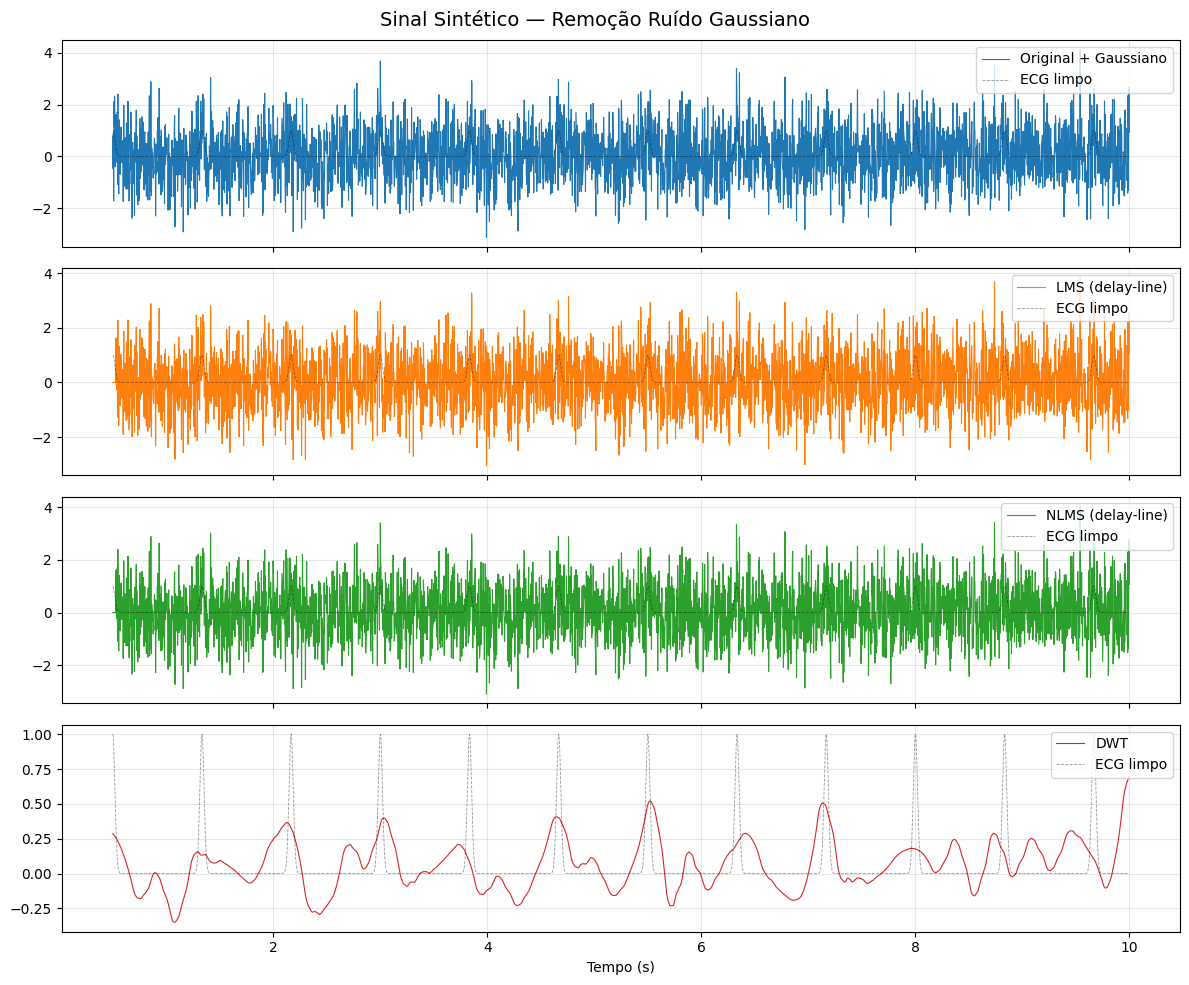

In [29]:
ecg_dwt_g = dwt_filter(ecg_ruidoso_g, wavelet='db4', nivel=6)

fig, axs = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Sinal Sintético — Remoção Ruído Gaussiano', fontsize=14)
for ax, sig, label, cor in zip(axs,
        [ecg_ruidoso_g, ecg_lms_g, ecg_nlms_g, ecg_dwt_g],
        ['Original + Gaussiano', 'LMS (delay-line)', 'NLMS (delay-line)', 'DWT'],
        ['tab:blue','tab:orange','tab:green','tab:red']):
    ax.plot(tempo, sig,  color=cor, linewidth=0.8, label=label)
    ax.plot(tempo, ecg, 'k--', linewidth=0.6, alpha=0.4, label='ECG limpo')
    ax.legend(loc='upper right'); ax.grid(alpha=0.3)
axs[-1].set_xlabel('Tempo (s)'); plt.tight_layout(); plt.show()


In [30]:
print("=== SNR Sintético — Ruído Gaussiano ===")
print("Antes da filtragem   :", comparar_sinais(ecg, ecg_ruidoso_g))
print("LMS  (delay-line)    :", comparar_sinais(ecg, ecg_lms_g))
print("NLMS (delay-line)    :", comparar_sinais(ecg, ecg_nlms_g))
print("DWT                  :", comparar_sinais(ecg, ecg_dwt_g))


=== SNR Sintético — Ruído Gaussiano ===
Potência sinal: 0.0430582394312799
Potência erro: 0.9856919815076809
Antes da filtragem   : -13.596849552493882
Potência sinal: 0.0430582394312799
Potência erro: 1.040478121680553
LMS  (delay-line)    : -13.831766842727955
Potência sinal: 0.0430582394312799
Potência erro: 0.9925443829720249
NLMS (delay-line)    : -13.626936675546377
Potência sinal: 0.0430582394312799
Potência erro: 0.04655389975362134
DWT                  : -0.33899798685858357


### Interpretação dos Resultados — Ruído Gaussiano

| Método | SNR esperado | Razão |
|--------|-------------|-------|
| LMS (delay-line)  | Baixo a moderado | Correlação limitada entre sinal atrasado e ruído branco |
| NLMS (delay-line) | Similar ao LMS | Normalização ajuda estabilidade mas não resolve a correlação |
| DWT               | **Mais alto** | Threshold de Donoho & Johnstone derivado especificamente para ruído gaussiano |

**Conclusão:** Para ruído aleatório/EMG, a **DWT é o método mais indicado**.

In [31]:
# Salva SNRs sintéticos para uso no módulo de resultados
snr_sintetico = {
    '60Hz':  {
        'LMS':  comparar_sinais(ecg, ecg_lms),
        'NLMS': comparar_sinais(ecg, ecg_nlms),
        'DWT':  comparar_sinais(ecg, ecg_dwt),
    },
    '0.2Hz': {
        'LMS':  comparar_sinais(ecg, ecg_lms_02),
        'NLMS': comparar_sinais(ecg, ecg_nlms_02),
        'DWT':  comparar_sinais(ecg, ecg_dwt_02),
    },
    'Gaussiano': {
        'LMS':  comparar_sinais(ecg, ecg_lms_g),
        'NLMS': comparar_sinais(ecg, ecg_nlms_g),
        'DWT':  comparar_sinais(ecg, ecg_dwt_g),
    },
}
print("SNRs sintéticos salvos em snr_sintetico.")


Potência sinal: 0.0430582394312799
Potência erro: 0.006387973877508796
Potência sinal: 0.0430582394312799
Potência erro: 0.005935575091358185
Potência sinal: 0.0430582394312799
Potência erro: 0.1687470090773193
Potência sinal: 0.0430582394312799
Potência erro: 0.026890908998597734
Potência sinal: 0.0430582394312799
Potência erro: 0.02057096801802034
Potência sinal: 0.0430582394312799
Potência erro: 0.5199669224161239
Potência sinal: 0.0430582394312799
Potência erro: 1.040478121680553
Potência sinal: 0.0430582394312799
Potência erro: 0.9925443829720249
Potência sinal: 0.0430582394312799
Potência erro: 0.04655389975362134
SNRs sintéticos salvos em snr_sintetico.
